In [1]:
import os
foldername = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/'
os.makedirs(foldername, exist_ok=True)

## Configuration
Edit this cell to add windows as runs complete. All other cells run without modification.

In [2]:
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import pandas as pd
import numpy as np
from forecasts.forecast_utils import get_forecast_params

# ── All 4-month forecast windows ─────────────────────────────────────────────
ALL_WINDOWS = [
    pd.Timestamp('2012-09-01'),
    pd.Timestamp('2012-11-01'),
    pd.Timestamp('2013-01-01'),
    pd.Timestamp('2013-03-01'),
    pd.Timestamp('2013-05-01'),
    pd.Timestamp('2013-07-01'),
]

# ── TPOSE-Vel State Estimate: manual dirs (naming convention varies by run) ───
# Set None for windows not yet available; windows without vel estimate omitted.
VEL_EST_DIRS = {
    pd.Timestamp('2012-09-01'): '/data/SO3/edavenport/tpose6/sep2012/velocity_assim_0825/run_iter22',
    pd.Timestamp('2012-11-01'): '/data/SO3/edavenport/tpose6/nov2012/run_iter20',
    pd.Timestamp('2013-01-01'): '/data/SO3/edavenport/tpose6/jan2013/run_iter14',
    pd.Timestamp('2013-03-01'): '/data/SO3/edavenport/tpose6/mar2013/run_iter16',
}

# ── Vel estimate itPerFile override ──────────────────────────────────────────
# Only needed when vel estimate timestep differs from noVel estimate for that window.
# sep2012: noVel uses 48 iters/day (1800s), but run_iter24 uses 72 iters/day (1200s).
VEL_EST_ITERS_PER_FILE = {
    pd.Timestamp('2012-09-01'): 72,
}

# ── Data paths (single location for all windows) ──────────────────────────────
GLORYS_T_PATH = '/data/SO3/edavenport/tpose6/glorys_T_data/glorys_*.nc'
HYCOM_DIR     = '/data/SO3/edavenport/tpose6/hycom_data/'  # hycom_T_{YYYY}_{MM:02d}.nc
OISST_OBS     = '/data/SO3/edavenport/tpose6/oisst_data/oisst_equatorial_pacific_2012to2013.nc'
OISST_CLIM    = 'forecasts/oisst_data/oisst_climatology_1993to2012.nc'

# ── Spatial domain ────────────────────────────────────────────────────────────
lonMin, lonMax = 180, 260
latMin, latMax = -10, 10

In [3]:
import matplotlib.pyplot as plt
import xarray as xr
from xmitgcm import open_mdsdataset
plt.rcParams['font.size'] = 14


def load_hycom_T_daily(start_date, end_date):
    """Load HYCOM temperature files for a date window; returns daily-mean dataset or None."""
    months = pd.date_range(
        start=pd.Timestamp(start_date).to_period('M').to_timestamp(),
        end=pd.Timestamp(end_date).to_period('M').to_timestamp(),
        freq='MS',
    )
    files = [
        HYCOM_DIR + f'hycom_T_{m.year}_{m.month:02d}.nc'
        for m in months
        if os.path.exists(HYCOM_DIR + f'hycom_T_{m.year}_{m.month:02d}.nc')
    ]
    if not files:
        return None
    ds = xr.open_mfdataset(files, combine='by_coords')
    ds = ds.sel(time=slice(str(start_date)[:10], str(end_date)[:10])).resample(time='1D').mean()
    full_index = pd.date_range(start_date, end_date, freq='1D')
    return ds.reindex(time=full_index)


oisst_obs  = xr.open_dataset(OISST_OBS)
oisst_obs  = oisst_obs.assign_coords(longitude=(oisst_obs.longitude % 360)).sortby('longitude')
oisst_clim = xr.open_dataset(OISST_CLIM)
oisst_clim = oisst_clim.assign_coords(longitude=(oisst_clim.longitude % 360)).sortby('longitude')

glorys_T = xr.open_mfdataset(GLORYS_T_PATH, combine='by_coords')
glorys_T = glorys_T.assign_coords(longitude=(glorys_T.longitude % 360)).sortby('longitude')

print('Static datasets loaded.')
print('OISST obs time range:', str(oisst_obs.time.values[0])[:10], '->', str(oisst_obs.time.values[-1])[:10])

Static datasets loaded.
OISST obs time range: 2012-01-01 -> 2013-12-31


In [4]:
# ── Per-window RMSE loop ──────────────────────────────────────────────────────

import copy
prefix = ['diag_state']

PRODUCT_KEYS = [
    'noVel_est', 'noVel_fct', 'noVel_pers',
    'vel_est',   'vel_fct',   'vel_pers',
    'glorys',    'hycom',
]
rmse_lists = {k: [] for k in PRODUCT_KEYS}
n_wins     = {k: 0  for k in PRODUCT_KEYS}
max_days   = 0


def open_tpose_win(data_dir, p):
    ds = open_mdsdataset(
        data_dir=data_dir, grid_dir=p.grid_dir,
        iters=p.intervals, prefix=prefix,
        ref_date=p.ref_date, delta_t=p.delta_t)
    for coord in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds[coord] = ds[coord].astype(float)
    return ds


def vel_est_params(win_start, p):
    """Return params with itPerFile/intervals overridden for the vel estimate if needed."""
    ipf = VEL_EST_ITERS_PER_FILE.get(win_start)
    if ipf is None or ipf == p.itPerFile:
        return p
    p2 = copy.copy(p)
    p2.itPerFile = ipf
    p2.delta_t   = 1440 / ipf * 60
    p2.intervals = range(ipf, ipf * (p.n_forecast_days + 1), ipf)
    return p2


def spatial_rmse(model_vals, obs_vals, w_norm):
    """Weighted spatial RMSE; shape (n_time, n_lat, n_lon) -> (n_time,)."""
    diff = model_vals - obs_vals
    return np.sqrt(np.nansum(diff**2 * w_norm, axis=(1, 2)))


for win_start in ALL_WINDOWS:
    p       = get_forecast_params(win_start)
    win_end = p.end_date
    wlabel  = f"{p.month_str}{p.year_str}"
    print(f'\n=== {win_start.date()} -> {win_end.date()} ===')

    # ── resolve directories ───────────────────────────────────────
    # vel_est_dir may be None; when absent, noVel_est/GLORYS/HYCOM are excluded
    # but forecasts are still included if their directories exist.
    vel_est_dir   = VEL_EST_DIRS.get(win_start)
    novel_est_dir = p.noTAO_data_dir          if os.path.isdir(p.noTAO_data_dir)          else None
    vel_fct_dir   = p.vel_forecast_data_dir   if os.path.isdir(p.vel_forecast_data_dir)   else None
    novel_fct_dir = p.noTAO_forecast_data_dir if os.path.isdir(p.noTAO_forecast_data_dir) else None

    for name, d in [('noVel est', novel_est_dir), ('noVel fct', novel_fct_dir),
                    ('vel est',   vel_est_dir),   ('vel fct',   vel_fct_dir)]:
        print(f'  {name:10s}: {d or "MISSING"}')

    # ── load available TPOSE datasets ─────────────────────────────
    p_vel        = vel_est_params(win_start, p)
    ds_novel_est = open_tpose_win(novel_est_dir,  p)     if novel_est_dir  else None
    ds_novel_fct = open_tpose_win(novel_fct_dir,  p)     if novel_fct_dir  else None
    ds_vel_est   = open_tpose_win(vel_est_dir,    p_vel) if vel_est_dir    else None
    ds_vel_fct   = open_tpose_win(vel_fct_dir,    p)     if vel_fct_dir    else None

    ref_ds = ds_novel_est or ds_vel_est or ds_novel_fct or ds_vel_fct
    if ref_ds is None:
        print(f'  No TPOSE data for {wlabel}, skipping window.')
        continue

    tpose_xc = ref_ds.XC.sel(XC=slice(lonMin, lonMax)).values
    tpose_yc = ref_ds.YC.sel(YC=slice(latMin, latMax)).values
    lat_w    = np.cos(np.deg2rad(tpose_yc))
    lat_w2   = lat_w[:, np.newaxis] * np.ones(len(tpose_xc))
    w_norm   = lat_w2 / np.nansum(lat_w2)

    n_days   = p.n_forecast_days
    max_days = max(max_days, n_days)

    # ── OISST obs for this window ─────────────────────────────────
    oisst_win = (
        oisst_obs.sst
        .sel(time=slice(win_start.strftime('%Y-%m-%d'), win_end.strftime('%Y-%m-%d')),
             latitude=slice(latMin, latMax), longitude=slice(lonMin, lonMax))
        .isel(time=p.eval_slice)
        .interp(longitude=tpose_xc, latitude=tpose_yc, method='linear')
        .compute()
    ).values

    # ── TPOSE surface temperature ─────────────────────────────────
    def load_theta_surf(ds):
        da = (
            ds.THETA
            .isel(Z=0)
            .sel(XC=slice(lonMin, lonMax), YC=slice(latMin, latMax))
            .isel(time=p.eval_slice)
            .compute()
        )
        return da.where(da != 0).values

    def add_rmse(ds, key):
        if ds is None:
            return
        arr = load_theta_surf(ds)
        rmse_lists[key].append(spatial_rmse(arr, oisst_win, w_norm))
        n_wins[key] += 1

    def add_persistence_rmse(ds, key):
        if ds is None:
            return
        arr   = load_theta_surf(ds)
        field = arr[0]
        rmse_lists[key].append(spatial_rmse(np.broadcast_to(field, arr.shape), oisst_win, w_norm))
        n_wins[key] += 1

    # Forecasts: always included when data exists
    add_rmse(ds_novel_fct, 'noVel_fct')
    add_rmse(ds_vel_est,   'vel_est')
    add_rmse(ds_vel_fct,   'vel_fct')
    add_persistence_rmse(ds_novel_fct, 'noVel_pers')
    add_persistence_rmse(ds_vel_fct,   'vel_pers')

    # State estimates and reanalysis: only when vel estimate exists for this window
    if vel_est_dir is not None:
        add_rmse(ds_novel_est, 'noVel_est')

        glorys_win = (
            glorys_T.thetao
            .isel(depth=0)
            .sel(time=slice(win_start.strftime('%Y-%m-%d'), win_end.strftime('%Y-%m-%d')),
                 latitude=slice(latMin, latMax), longitude=slice(lonMin, lonMax))
            .isel(time=p.eval_slice)
            .interp(longitude=tpose_xc, latitude=tpose_yc, method='linear')
            .compute()
        ).values
        rmse_lists['glorys'].append(spatial_rmse(glorys_win, oisst_win, w_norm))
        n_wins['glorys'] += 1

        hycom_T = load_hycom_T_daily(win_start, win_end)
        if hycom_T is not None:
            hycom_r   = hycom_T.assign_coords(lon=(hycom_T.lon % 360)).sortby('lon')
            hycom_win = (
                hycom_r.water_temp
                .sel(depth=0.0, lat=slice(latMin, latMax), lon=slice(lonMin, lonMax))
                .isel(time=p.eval_slice)
                .interp(lon=tpose_xc, lat=tpose_yc, method='linear')
                .compute()
            ).values
            rmse_lists['hycom'].append(spatial_rmse(hycom_win, oisst_win, w_norm))
            n_wins['hycom'] += 1
        else:
            print(f'  HYCOM T: no data for {wlabel}')
    else:
        print(f'  vel est MISSING — noVel_est, GLORYS, HYCOM excluded for {wlabel}')

    print(f'  {wlabel} complete.')

print('\nWindows available per product:')
for k, n in n_wins.items():
    print(f'  {k:15s}: {n}')


=== 2012-09-01 -> 2012-12-31 ===
  noVel est : /data/SO6/TPOSE_diags/tpose6/sep2012/diags_iter7_daily/
  noVel fct : MISSING
  vel est   : /data/SO3/edavenport/tpose6/sep2012/velocity_assim_0825/run_iter22
  vel fct   : MISSING
  sep2012 complete.

=== 2012-11-01 -> 2013-02-28 ===
  noVel est : /data/SO6/TPOSE_diags/tpose6/nov2012/diags_new/
  noVel fct : MISSING
  vel est   : /data/SO3/edavenport/tpose6/nov2012/run_iter20
  vel fct   : MISSING
  nov2012 complete.

=== 2013-01-01 -> 2013-04-30 ===
  noVel est : /data/SO3/averdy/TPOSE6/jan2013/diags_daily/
  noVel fct : /data/SO3/edavenport/tpose6/forecasts/jan012013_tpose_noVel/
  vel est   : /data/SO3/edavenport/tpose6/jan2013/run_iter14
  vel fct   : MISSING
  jan2013 complete.

=== 2013-03-01 -> 2013-06-30 ===
  noVel est : /data/SO3/averdy/TPOSE6/mar2013/diags_daily/
  noVel fct : /data/SO3/edavenport/tpose6/forecasts/mar012013_tpose_noVel/
  vel est   : /data/SO3/edavenport/tpose6/mar2013/run_iter16
  vel fct   : MISSING
  mar201

In [5]:
# ── Average RMSE across windows ───────────────────────────────────────────────

def avg_over_windows(arrays, max_days):
    """NaN-pad arrays to max_days and nanmean across windows."""
    if not arrays:
        return None
    stacked = np.full((len(arrays), max_days), np.nan)
    for i, arr in enumerate(arrays):
        stacked[i, :len(arr)] = arr
    return np.nanmean(stacked, axis=0)


rmse_avg = {k: avg_over_windows(v, max_days) for k, v in rmse_lists.items()}
days_avg = np.arange(1, max_days + 1)

# ── Climatology baseline: area-weighted RMS of sst_std, averaged across windows
# sqrt(weighted_mean(σ²)) matches the same L2 norm used by spatial_rmse
clim_region = oisst_clim.sst_std.sel(
    latitude=slice(latMin, latMax), longitude=slice(lonMin, lonMax))
clim_lat_w  = np.cos(np.deg2rad(clim_region.latitude.values))
clim_lat_w2 = clim_lat_w[:, np.newaxis] * np.ones(len(clim_region.longitude))
clim_w_norm = clim_lat_w2 / np.nansum(clim_lat_w2)
month_baselines = {
    m: float(np.sqrt(np.nansum(clim_region.sel(month=m).values**2 * clim_w_norm)))
    for m in range(1, 13)
}

baseline_lists = []
for win_start in ALL_WINDOWS:
    p = get_forecast_params(win_start)
    dates = pd.date_range(win_start, periods=p.n_forecast_days)
    baseline_lists.append(np.array([month_baselines[d.month] for d in dates]))
baseline_avg = avg_over_windows(baseline_lists, max_days)

print(f'Averaging over max {max_days} days.')
print(f'Baseline range: {baseline_avg.min():.3f}–{baseline_avg.max():.3f} °C')

Averaging over max 122 days.
Baseline range: 0.841–0.899 °C


/tmp/ipykernel_2866773/3251023201.py:10: RuntimeWarning: Mean of empty slice
  return np.nanmean(stacked, axis=0)


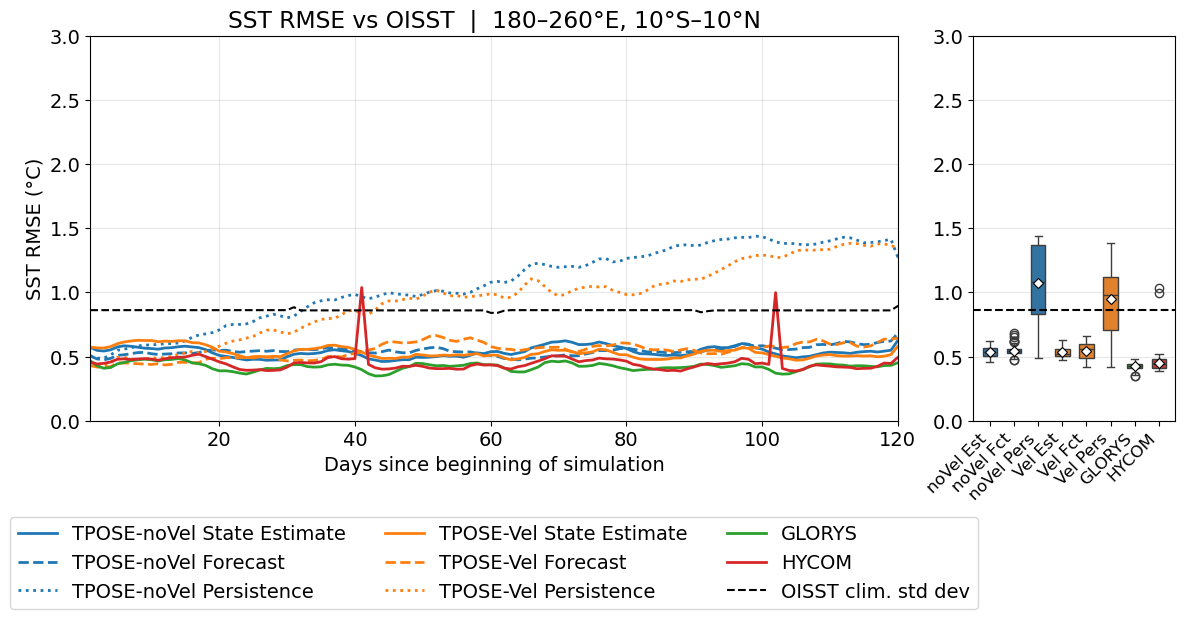

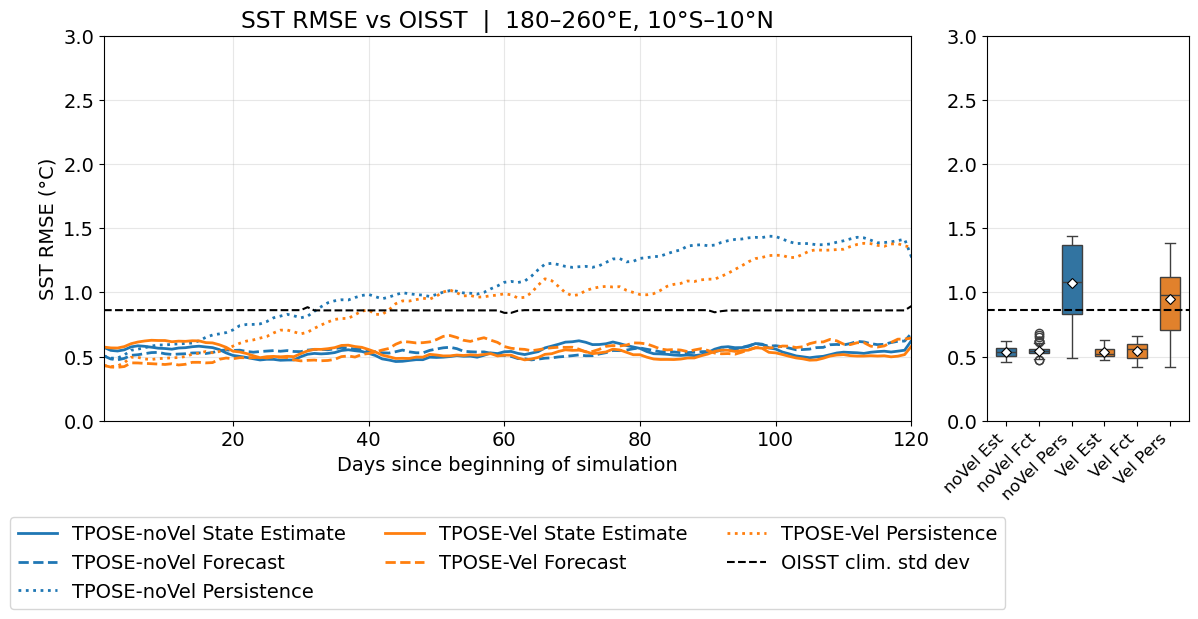

In [6]:
import seaborn as sns
import matplotlib.gridspec as gridspec

ylim = (0, 3.0)

specs = [
    ('noVel_est',  'TPOSE-noVel State Estimate', 'noVel Est',  'C0', '-'),
    ('noVel_fct',  'TPOSE-noVel Forecast',        'noVel Fct',  'C0', '--'),
    ('noVel_pers', 'TPOSE-noVel Persistence',     'noVel Pers', 'C0', ':'),
    ('vel_est',    'TPOSE-Vel State Estimate',     'Vel Est',    'C1', '-'),
    ('vel_fct',    'TPOSE-Vel Forecast',           'Vel Fct',    'C1', '--'),
    ('vel_pers',   'TPOSE-Vel Persistence',        'Vel Pers',   'C1', ':'),
    ('glorys',     'GLORYS',                       'GLORYS',     'C2', '-'),
    ('hycom',      'HYCOM',                        'HYCOM',      'C3', '-'),
]

datasets_all = [
    (rmse_avg[k], long, short, color, ls)
    for k, long, short, color, ls in specs
    if rmse_avg[k] is not None
]
tpose_shorts = {'noVel Est', 'noVel Fct', 'noVel Pers', 'Vel Est', 'Vel Fct', 'Vel Pers'}
datasets_tpose = [d for d in datasets_all if d[2] in tpose_shorts]

for datasets, suffix in [(datasets_all, ''), (datasets_tpose, '_tpose_only')]:
    short_names = [ds[2] for ds in datasets]
    palette     = [ds[3] for ds in datasets]

    fig  = plt.figure(figsize=(14, 5))
    gs   = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)
    ax   = fig.add_subplot(gs[0])
    ax_b = fig.add_subplot(gs[1])

    for data, long_name, _, color, ls in datasets:
        ax.plot(days_avg, data, color=color, lw=2, ls=ls, label=long_name)
    ax.plot(days_avg, baseline_avg, color='k', lw=1.5, ls='--', label='OISST clim. std dev')

    ax.set_xlabel('Days since beginning of simulation')
    ax.set_ylabel('SST RMSE (°C)')
    ax.set_title('SST RMSE vs OISST  |  180–260°E, 10°S–10°N')
    ax.set_xlim(days_avg[0], days_avg[-1]-2)
    ax.set_ylim(ylim)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, borderaxespad=0)

    ts_data   = [ds[0] for ds in datasets]
    col_names = [f'ds{k}' for k in range(len(ts_data))]
    all_vals  = [d[~np.isnan(d)] for d in ts_data]
    box_df    = pd.DataFrame({n: pd.Series(v) for n, v in zip(col_names, all_vals)})
    pal_dict  = dict(zip(col_names, palette))
    sns.boxplot(data=box_df, ax=ax_b, palette=pal_dict, width=0.6)
    for k, d in enumerate(ts_data):
        ax_b.plot(k, np.nanmean(d), marker='D', ms=5, color='white', mec='black', mew=0.8, zorder=5)
    ax_b.axhline(np.nanmedian(baseline_avg), color='k', lw=1.5, ls='--')
    ax_b.set_xticks(range(len(short_names)))
    ax_b.set_xticklabels(short_names, fontsize=12, rotation=45, ha='right')
    ax_b.set_ylabel('')
    ax_b.set_ylim(ylim)
    ax_b.grid(alpha=0.3, axis='y')

    plt.savefig(foldername + f'sst_rmse_vs_oisst_multi_window{suffix}.png',
                dpi=150, bbox_inches='tight')
    plt.show()